# Laboratorio: Isolation Forest sobre **4 KPIs** unidos (AIOps)

En este notebook unimos **cuatro métricas** del AIOps Challenge 2018 que comparten la misma ventana temporal (~146k puntos, 1 minuto, abr–jul 2017). Cada fila es un instante; cada columna es el `value` de un KPI distinto.

El objetivo es el mismo que en el laboratorio de un solo KPI: entrenar **Isolation Forest** multivariado, interpretar el ranking y comparar hiperparámetros — pero ahora las anomalías son **combinaciones raras entre métricas**, no solo rareza en una serie.

Dataset: [NetManAIOps / KPI-Anomaly-Detection](https://github.com/NetManAIOps/KPI-Anomaly-Detection) (competencia AIOps 2018).


## 0. Dependencias

Solo hace falta lo del bloque de imports. Los datos se descargan por HTTP si no están en `data/`.


In [1]:
# Sin instalaciones extra.


## 1. Imports y configuración

Usamos `pandas` para el join por `timestamp`, `scikit-learn` para Isolation Forest y `StandardScaler` (imprescindible al mezclar KPIs con escalas distintas).


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.tree import plot_tree

RANDOM_STATE = 42
plt.style.use("default")
pd.set_option("display.max_columns", 40)


## 2. Descargar dataset AIOps KPI

Mismo `phase2_train.csv` que en el laboratorio de un KPI. Tiene **29 KPI IDs**; solo usaremos **cuatro** del grupo “largo” (misma época, timestamps alineables).


In [3]:
import urllib.request
import zipfile

KPI_ZIP_URL = (
    "https://github.com/NetManAIOps/KPI-Anomaly-Detection/raw/master/"
    "Finals_dataset/phase2_train.csv.zip"
)
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
kpi_zip_path = DATA_DIR / "phase2_train.csv.zip"
kpi_csv_path = DATA_DIR / "phase2_train.csv"

if not kpi_csv_path.exists():
    print("Descargando AIOps KPI (puede tardar ~30 s)...")
    with urllib.request.urlopen(KPI_ZIP_URL, timeout=120) as resp:
        kpi_zip_path.write_bytes(resp.read())
    with zipfile.ZipFile(kpi_zip_path) as zf:
        zf.extract("phase2_train.csv", path=DATA_DIR)
    print("Guardado en:", kpi_csv_path.resolve())
else:
    print("Usando cache local:", kpi_csv_path.resolve())

kpi_all = pd.read_csv(kpi_csv_path)
kpi_all["timestamp"] = pd.to_datetime(kpi_all["timestamp"], unit="s")

kpi_summary = (
    kpi_all.groupby("KPI ID")
    .agg(
        puntos=("value", "size"),
        desde=("timestamp", "min"),
        hasta=("timestamp", "max"),
    )
    .sort_values("puntos", ascending=False)
)
print(f"KPIs disponibles: {len(kpi_summary)}  |  Filas totales: {len(kpi_all):,}")
kpi_summary.head(10)


Usando cache local: C:\Users\ericp\Documents\A9noSemestre\ElectivaAIOps\CarpetaObligatorio\AIOps\notebooks\data\phase2_train.csv
KPIs disponibles: 29  |  Filas totales: 3,004,066


,puntos,desde,hasta
KPI ID,,,
05f10d3a-239c-3bef-9bdc-a2feeb0037aa,146255,2017-04-01 10:08:00,2017-07-14 06:14:00
c69a50cf-ee03-3bd7-831e-407d36c7ee91,146255,2017-04-01 10:08:00,2017-07-14 06:14:00
1c6d7a26-1f1a-3321-bb4d-7a9d969ec8f0,146254,2017-04-01 10:08:00,2017-07-14 06:14:00
adb2fde9-8589-3f5b-a410-5fe14386c7af,146254,2017-04-01 10:08:00,2017-07-14 06:14:00
42d6616d-c9c5-370a-a8ba-17ead74f3114,146253,2017-04-01 10:08:00,2017-07-14 06:14:00
8723f0fb-eaef-32e6-b372-6034c9c04b80,146243,2017-04-01 10:08:00,2017-07-14 06:14:00
6d1114ae-be04-3c46-b5aa-be1a003a57cd,146239,2017-04-01 10:08:00,2017-07-14 06:14:00
847e8ecc-f8d2-3a93-9107-f367a0aab37d,146228,2017-04-01 10:08:00,2017-07-14 06:14:00
55f8b8b8-b659-38df-b3df-e4a5a8a54bc9,146204,2017-04-01 10:08:00,2017-07-14 06:14:00


## 3. Join de 4 KPIs por `timestamp`

Elegimos cuatro IDs del grupo con ~146k puntos (abr–jul 2017). El join es un `pivot`: una fila por minuto, una columna por KPI.

| Alias | KPI ID (primeros 8 chars) |
|-------|---------------------------|
| kpi_a | `05f10d3a...` |
| kpi_b | `c69a50cf...` |
| kpi_c | `1c6d7a26...` |
| kpi_d | `adb2fde9...` |

Usamos `dropna()` (join interno): descartamos minutos donde falte algún KPI. En la práctica pierde muy pocas filas.


In [4]:
KPI_IDS = ['05f10d3a-239c-3bef-9bdc-a2feeb0037aa', 'c69a50cf-ee03-3bd7-831e-407d36c7ee91', '1c6d7a26-1f1a-3321-bb4d-7a9d969ec8f0', 'adb2fde9-8589-3f5b-a410-5fe14386c7af']
SHORT_NAMES = ['kpi_a', 'kpi_b', 'kpi_c', 'kpi_d']
ID_TO_SHORT = dict(zip(KPI_IDS, SHORT_NAMES))

subset = kpi_all[kpi_all["KPI ID"].isin(KPI_IDS)].copy()
wide = (
    subset.pivot(index="timestamp", columns="KPI ID", values="value")
    .sort_index()
    .rename(columns=ID_TO_SHORT)
    .reset_index()
)
raw = wide.dropna().reset_index(drop=True)

print("Filas despues del join:", len(raw))
print("Columnas KPI:", SHORT_NAMES)
print(f"Desde {raw['timestamp'].min()} hasta {raw['timestamp'].max()}")
raw[SHORT_NAMES].describe().T


Filas despues del join: 146253
Columnas KPI: ['kpi_a', 'kpi_b', 'kpi_c', 'kpi_d']
Desde 2017-04-01 10:08:00 hasta 2017-07-14 06:14:00


,count,mean,std,min,25%,50%,75%,max
KPI ID,,,,,,,,
kpi_a,146253.0,34.438926,4.203548,0.0,31.55,34.15,36.84,98.33
kpi_b,146253.0,35.048789,5.692431,1.5,32.11,34.80,37.40,172.19
kpi_c,146253.0,35.539637,5.729775,1.7,32.59,35.30,37.95,172.42
kpi_d,146253.0,34.188606,5.287161,0.0,31.37,34.02,36.69,119.77


## 4. Primera mirada

Cuatro series en paralelo. Las escalas suelen diferir (el CSV no trae nombres legibles de métrica); por eso luego **estandarizamos** antes del IF.


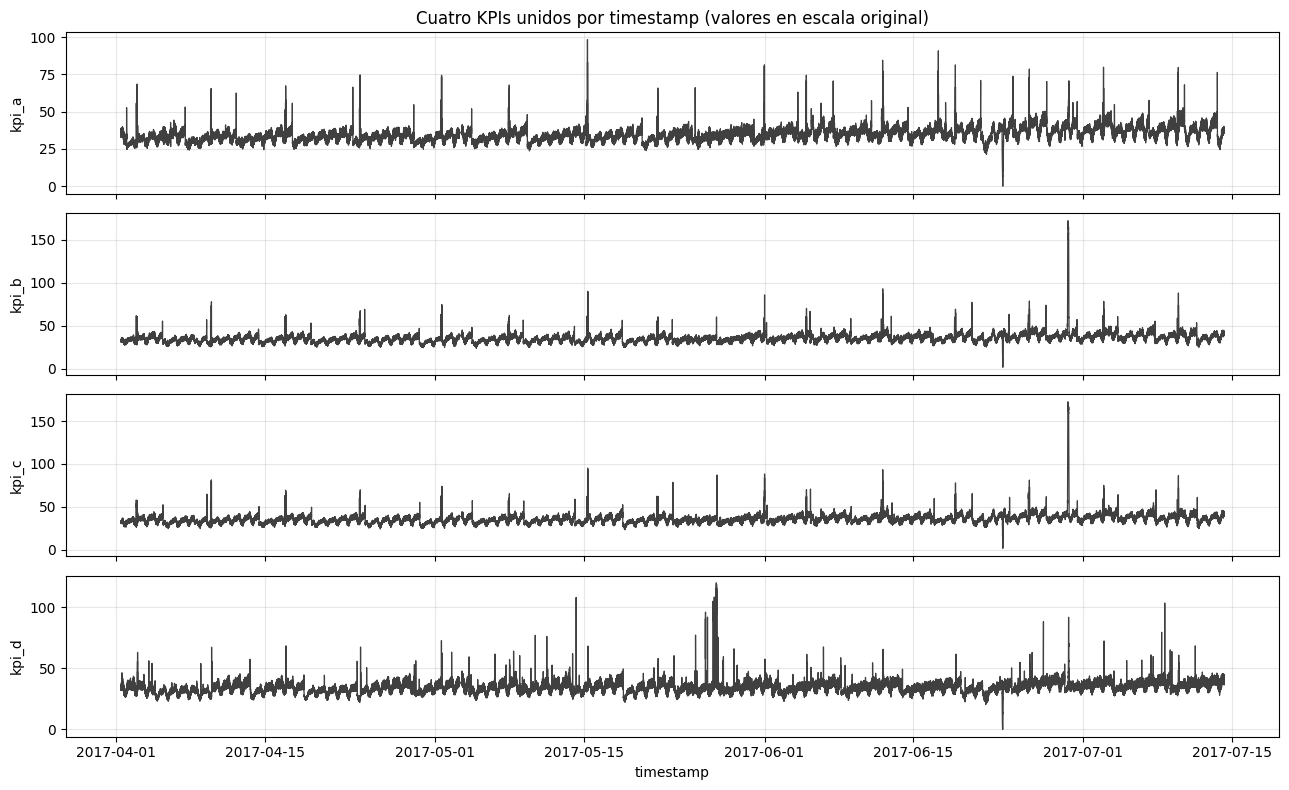

In [5]:
fig, axes = plt.subplots(len(SHORT_NAMES), 1, figsize=(13, 8), sharex=True)

for ax, name in zip(axes, SHORT_NAMES):
    ax.plot(raw["timestamp"], raw[name], color="0.25", linewidth=0.9)
    ax.set_ylabel(name)
    ax.grid(True, alpha=0.3)

axes[0].set_title("Cuatro KPIs unidos por timestamp (valores en escala original)")
axes[-1].set_xlabel("timestamp")
plt.tight_layout()
plt.show()


## 5. Construcción de features

Por cada KPI calculamos `value`, `diff_1` y `rolling_z` (ventana 12). Agregamos `hour` y `dayofweek` compartidos.

En total: 4 × 3 + 2 = **14 features** para el Isolation Forest multivariado.


### Qué es `rolling_z` (z-score móvil)

Para cada KPI, compara el valor actual con la media y el desvío de los últimos 12 minutos. Un pico en **una** métrica con las demás normales puede ser anómalo a nivel sistema.


In [6]:
def build_features_multikpi(df: pd.DataFrame, kpi_cols: list[str], window: int = 12) -> pd.DataFrame:
    data = df.copy()
    data["timestamp"] = pd.to_datetime(data["timestamp"])
    data = data.sort_values("timestamp").reset_index(drop=True)

    features = pd.DataFrame({"timestamp": data["timestamp"]})
    for col in kpi_cols:
        y = data[col].astype(float)
        features[col] = y
        features[f"{col}_diff_1"] = y.diff()
        roll_mean = y.rolling(window, min_periods=3).mean()
        roll_std = y.rolling(window, min_periods=3).std()
        features[f"{col}_rolling_z"] = (y - roll_mean) / roll_std.replace(0, np.nan)

    features["hour"] = features["timestamp"].dt.hour
    features["dayofweek"] = features["timestamp"].dt.dayofweek
    return features.dropna().reset_index(drop=True)


features = build_features_multikpi(raw, SHORT_NAMES, window=12)
features.head()


,timestamp,kpi_a,kpi_a_diff_1,kpi_a_rolling_z,kpi_b,kpi_b_diff_1,kpi_b_rolling_z,kpi_c,kpi_c_diff_1,kpi_c_rolling_z,kpi_d,kpi_d_diff_1,kpi_d_rolling_z,hour,dayofweek
0,2017-04-01 10:10:00,32.79,-3.81,-1.053203,33.06,0.86,0.992339,31.82,-0.43,-0.810026,34.40,1.41,0.359050,10,5
1,2017-04-01 10:11:00,34.28,1.49,-0.249142,32.35,-0.71,0.169385,32.94,1.12,0.437932,33.53,-0.87,-0.486341,10,5
2,2017-04-01 10:12:00,34.69,0.41,0.008740,32.69,0.34,0.560960,33.20,0.26,0.678454,35.45,1.92,1.240136,10,5
3,2017-04-01 10:13:00,35.30,0.61,0.413320,32.27,-0.42,-0.070585,32.70,-0.50,-0.049029,32.96,-2.49,-1.038737,10,5
4,2017-04-01 10:14:00,35.25,-0.05,0.346534,32.77,0.50,0.694057,32.55,-0.15,-0.274189,33.44,0.48,-0.519478,10,5


## 6. Matriz de entrenamiento

Mezclamos KPIs con unidades distintas → `StandardScaler` sobre todas las columnas numéricas.


In [7]:
feature_cols = ['kpi_a', 'kpi_a_diff_1', 'kpi_a_rolling_z', 'kpi_b', 'kpi_b_diff_1', 'kpi_b_rolling_z', 'kpi_c', 'kpi_c_diff_1', 'kpi_c_rolling_z', 'kpi_d', 'kpi_d_diff_1', 'kpi_d_rolling_z', 'hour', 'dayofweek']

X = features[feature_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Filas para entrenar:", X.shape[0])
print("N features:", len(feature_cols))


Filas para entrenar: 146218
N features: 14


## 7. Entrenar Isolation Forest

Parámetros principales (se fijan **al crear y entrenar** el modelo con `fit()`):

- `n_estimators = m`: cantidad de árboles.
- `max_samples = ψ`: tamaño de submuestra por árbol.
- `contamination`: proporción del ranking que se etiqueta como anomalía.

Entrenamos **tres configuraciones** sobre la misma matriz para comparar cómo cambian las etiquetas.


In [8]:
psi = min(256, len(features))

MODEL_CONFIGS = [
    {"name": "base", "label": "base (m=200, contamination=2%)", "m": 200, "contamination": 0.02},
    {"name": "pocas_alertas", "label": "pocas alertas (m=200, contamination=0.5%)", "m": 200, "contamination": 0.005},
    {"name": "pocos_arboles", "label": "pocos arboles (m=50, contamination=2%)", "m": 50, "contamination": 0.02},
]


def fit_isolation_forest(X_scaled, m, psi, contamination):
    clf = IsolationForest(
        n_estimators=m,
        max_samples=psi,
        contamination=contamination,
        random_state=RANDOM_STATE,
    )
    pred = clf.fit_predict(X_scaled)
    scores = -clf.score_samples(X_scaled)
    return clf, scores, pred == -1


models = {}
for cfg in MODEL_CONFIGS:
    clf, scores, flags = fit_isolation_forest(
        X_scaled, cfg["m"], psi, cfg["contamination"]
    )
    models[cfg["name"]] = {
        "model": clf,
        "label": cfg["label"],
        "m": cfg["m"],
        "contamination": cfg["contamination"],
        "anomaly_score": scores,
        "is_anomaly": flags,
    }

base = models["base"]
model = base["model"]
m = base["m"]
contamination = base["contamination"]

results = features.copy()
results["anomaly_score"] = base["anomaly_score"]
results["is_anomaly"] = base["is_anomaly"]
for cfg in MODEL_CONFIGS:
    if cfg["name"] == "base":
        continue
    results[f"is_anomaly_{cfg['name']}"] = models[cfg["name"]]["is_anomaly"]

# Promedio de valores (solo para graficos; el IF usa todas las features)
results["value_mean"] = results[SHORT_NAMES].mean(axis=1)

comparison_rows = []
for cfg in MODEL_CONFIGS:
    if cfg["name"] == "base":
        continue
    flags = models[cfg["name"]]["is_anomaly"]
    comparison_rows.append(
        {
            "config": cfg["name"],
            "m": cfg["m"],
            "contamination": cfg["contamination"],
            "n_anomalies": int(flags.sum()),
            "overlap_con_base": int((flags & base["is_anomaly"]).sum()),
            "pct_etiquetas_distintas": round(100 * (flags != base["is_anomaly"]).mean(), 2),
        }
    )

display(pd.DataFrame(comparison_rows))
results[["timestamp", "value_mean", "anomaly_score", "is_anomaly"]].head()


,config,m,contamination,n_anomalies,overlap_con_base,pct_etiquetas_distintas
0,pocas_alertas,200,0.005,732,732,1.5
1,pocos_arboles,50,0.020,2925,2191,1.0


,timestamp,value_mean,anomaly_score,is_anomaly
0,2017-04-01 10:10:00,33.0175,0.437429,False
1,2017-04-01 10:11:00,33.2750,0.400240,False
2,2017-04-01 10:12:00,34.0075,0.405431,False
3,2017-04-01 10:13:00,33.3075,0.401374,False
4,2017-04-01 10:14:00,33.5025,0.391956,False


### Comparar las tres configuraciones

Misma matriz multivariada: `contamination` cambia **cuántos** puntos se etiquetan; `m` distinto con `contamination` fijo cambia **cuáles**.


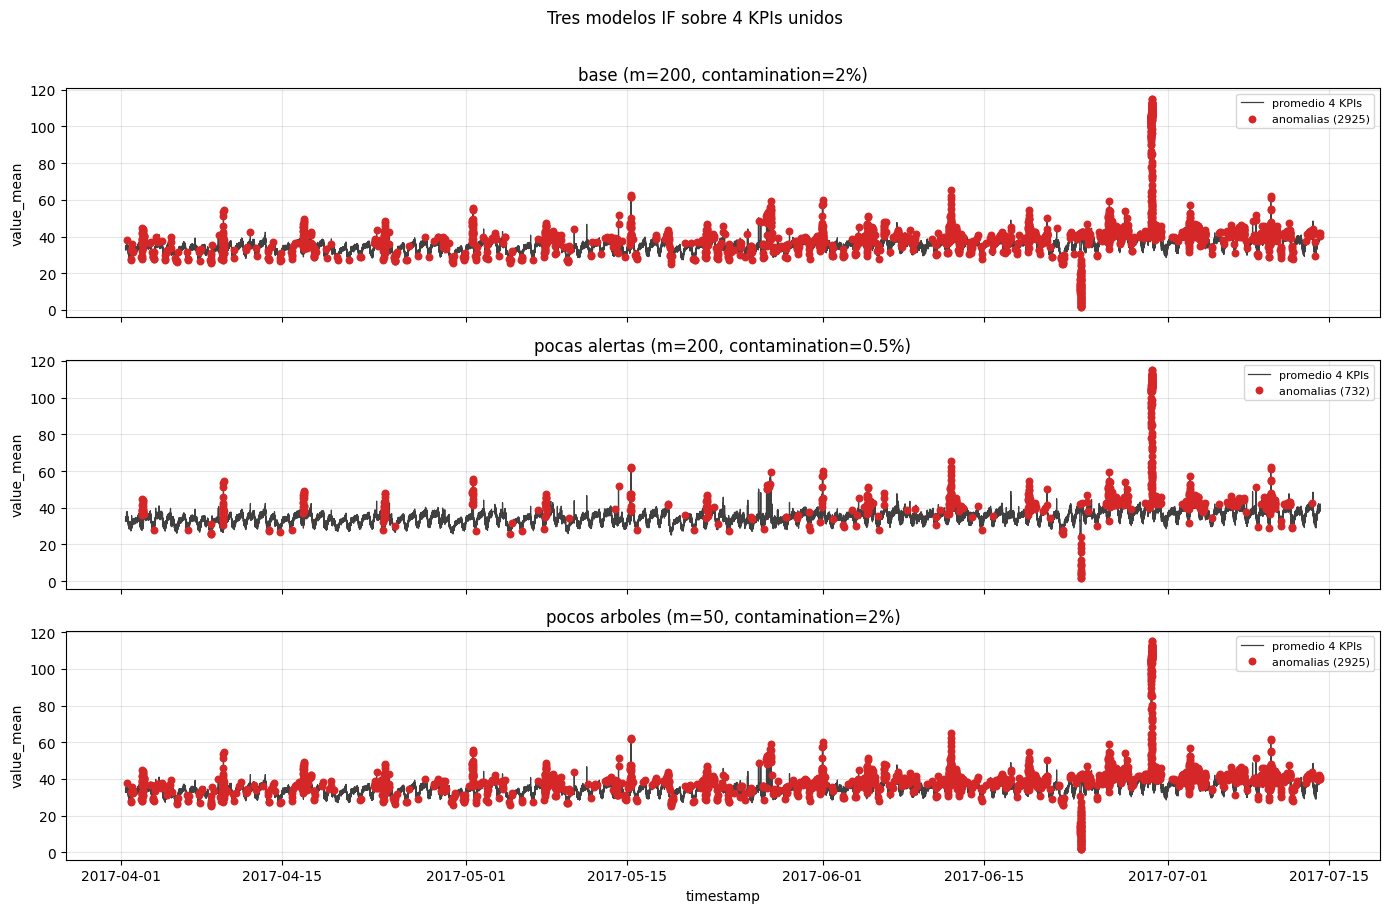

In [9]:
fig, axes = plt.subplots(len(MODEL_CONFIGS), 1, figsize=(14, 9), sharex=True)

for ax, cfg in zip(axes, MODEL_CONFIGS):
    flags = models[cfg["name"]]["is_anomaly"]
    n_flags = int(flags.sum())
    ax.plot(results["timestamp"], results["value_mean"], color="0.25", linewidth=0.9, label="promedio 4 KPIs")
    ax.scatter(
        results.loc[flags, "timestamp"],
        results.loc[flags, "value_mean"],
        color="tab:red",
        s=22,
        zorder=3,
        label=f"anomalias ({n_flags})",
    )
    ax.set_title(cfg["label"])
    ax.set_ylabel("value_mean")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("timestamp")
fig.suptitle("Tres modelos IF sobre 4 KPIs unidos", y=1.01)
plt.tight_layout()
plt.show()


## 8. Resultados: ranking y visualización

Top anomalías con los valores de los cuatro KPIs en ese minuto.


In [10]:
display_cols = ["timestamp", "anomaly_score", "is_anomaly"] + ['kpi_a', 'kpi_b', 'kpi_c', 'kpi_d']
top_anomalies = results.sort_values("anomaly_score", ascending=False).head(15)
top_anomalies[display_cols]


,timestamp,anomaly_score,is_anomaly,kpi_a,kpi_b,kpi_c,kpi_d
120740,2017-06-25 20:12:00,0.678442,True,37.26,61.83,65.02,36.06
126014,2017-06-29 15:09:00,0.674825,True,55.35,146.94,147.01,71.64
126007,2017-06-29 15:02:00,0.670290,True,49.76,155.13,155.62,87.64
126020,2017-06-29 15:16:00,0.669649,True,63.21,152.65,154.01,65.60
101655,2017-06-12 03:06:00,0.666023,True,38.68,58.53,60.55,62.97
126025,2017-06-29 15:21:00,0.662031,True,53.37,112.74,113.04,61.55
140322,2017-07-09 23:06:00,0.661665,True,38.08,78.59,79.30,48.54
126026,2017-06-29 15:22:00,0.660020,True,51.93,95.90,95.07,59.90
126023,2017-06-29 15:19:00,0.655052,True,53.51,138.60,137.54,65.05
101656,2017-06-12 03:07:00,0.654945,True,36.07,92.85,93.29,38.93


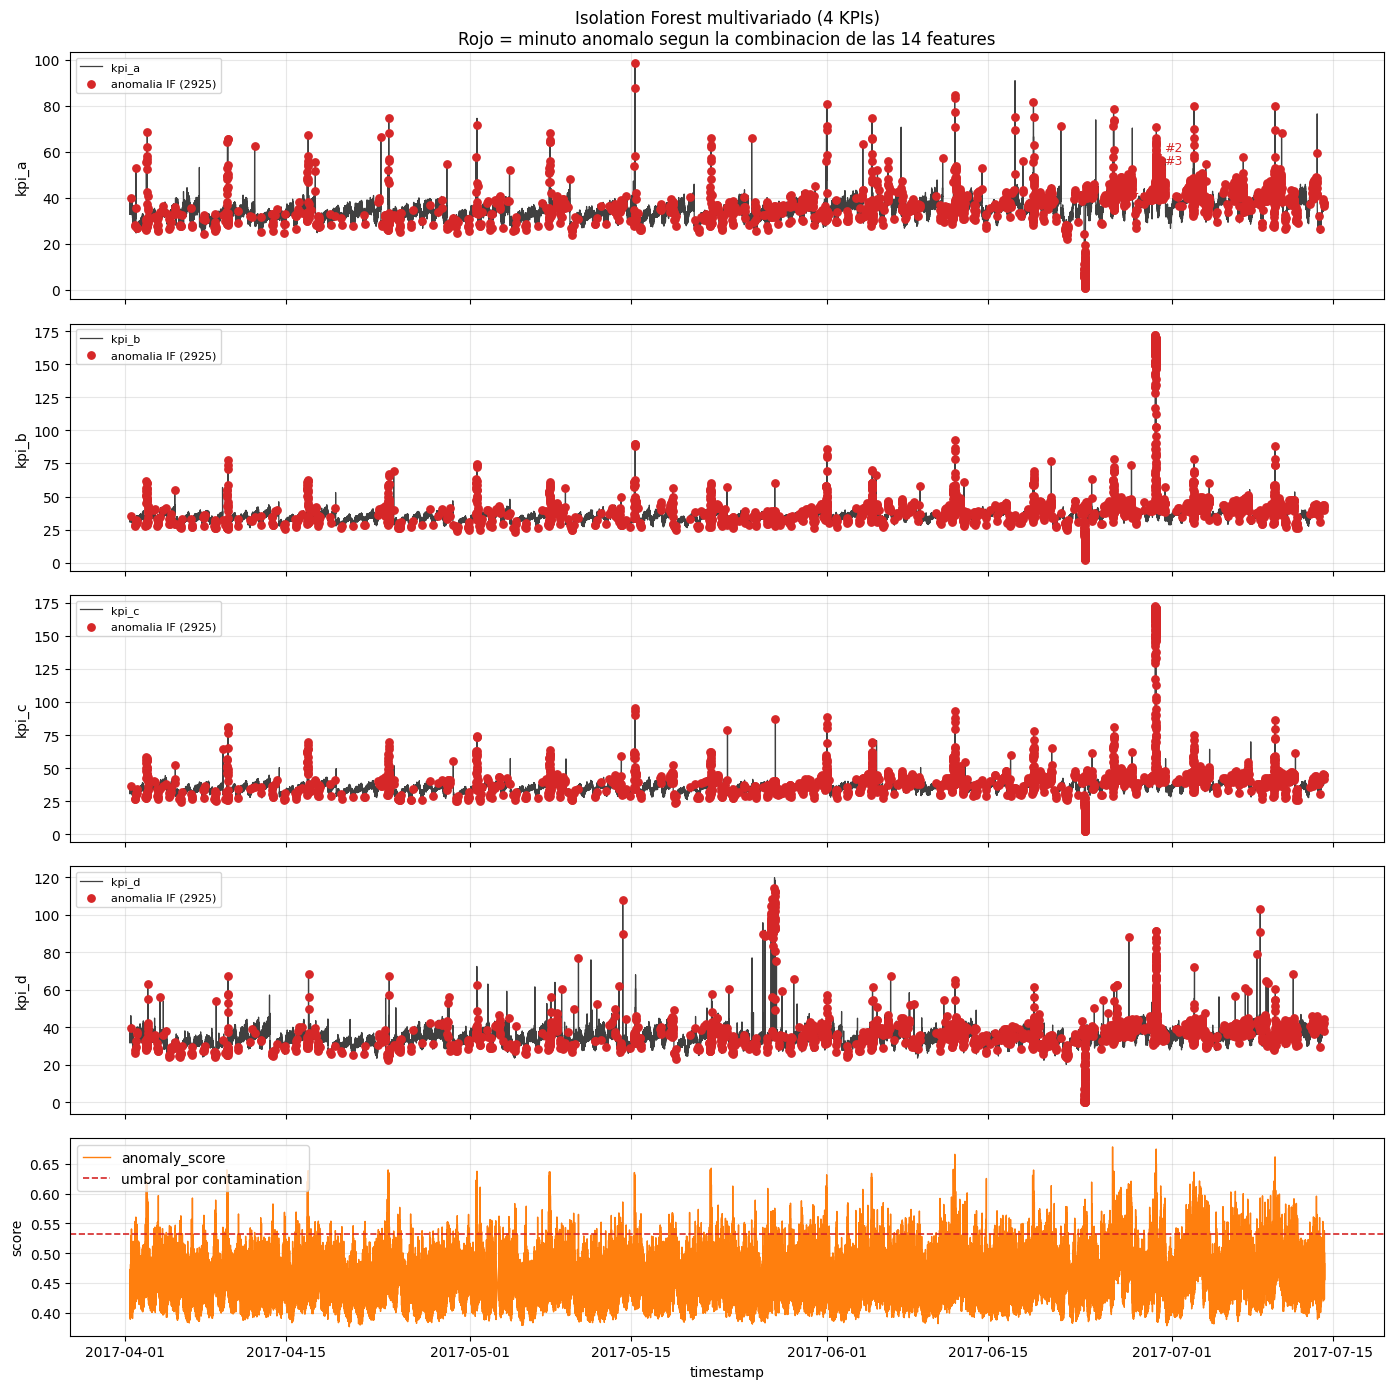

In [11]:
def annotate_top_points(ax, data, y_col, score_col="anomaly_score", n=3):
    top = data.sort_values(score_col, ascending=False).head(n)
    for rank, (_, row) in enumerate(top.iterrows(), start=1):
        ax.annotate(
            f"#{rank}",
            xy=(row["timestamp"], row[y_col]),
            xytext=(6, 8),
            textcoords="offset points",
            fontsize=9,
            color="tab:red",
            arrowprops={"arrowstyle": "->", "color": "tab:red", "lw": 0.8},
        )


threshold = results.loc[results["is_anomaly"], "anomaly_score"].min()
n_anomalies = int(results["is_anomaly"].sum())

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True, gridspec_kw={"height_ratios": [1.5, 1.5, 1.5, 1.5, 1.2]})

for ax, name in zip(axes[:4], SHORT_NAMES):
    ax.plot(results["timestamp"], results[name], linewidth=0.9, color="0.25", label=name)
    ax.scatter(
        results.loc[results["is_anomaly"], "timestamp"],
        results.loc[results["is_anomaly"], name],
        color="tab:red",
        s=28,
        zorder=3,
        label=f"anomalia IF ({n_anomalies})",
    )
    if name == SHORT_NAMES[0]:
        annotate_top_points(ax, results, y_col=name, n=3)
    ax.set_ylabel(name)
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_title(
    "Isolation Forest multivariado (4 KPIs)\n"
    "Rojo = minuto anomalo segun la combinacion de las 14 features"
)

ax = axes[4]
ax.plot(results["timestamp"], results["anomaly_score"], linewidth=1, color="tab:orange", label="anomaly_score")
ax.axhline(threshold, color="tab:red", linestyle="--", linewidth=1.2, label="umbral por contamination")
ax.fill_between(
    results["timestamp"],
    threshold,
    results["anomaly_score"],
    where=results["anomaly_score"] >= threshold,
    color="tab:red",
    alpha=0.15,
    interpolate=True,
)
ax.set_ylabel("score")
ax.set_xlabel("timestamp")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Visualizar un iTree

Proyectamos en 2D: `kpi_a` vs `kpi_b` (estandarizados). El árbol particiona el plano según **combinaciones** de ambas métricas.


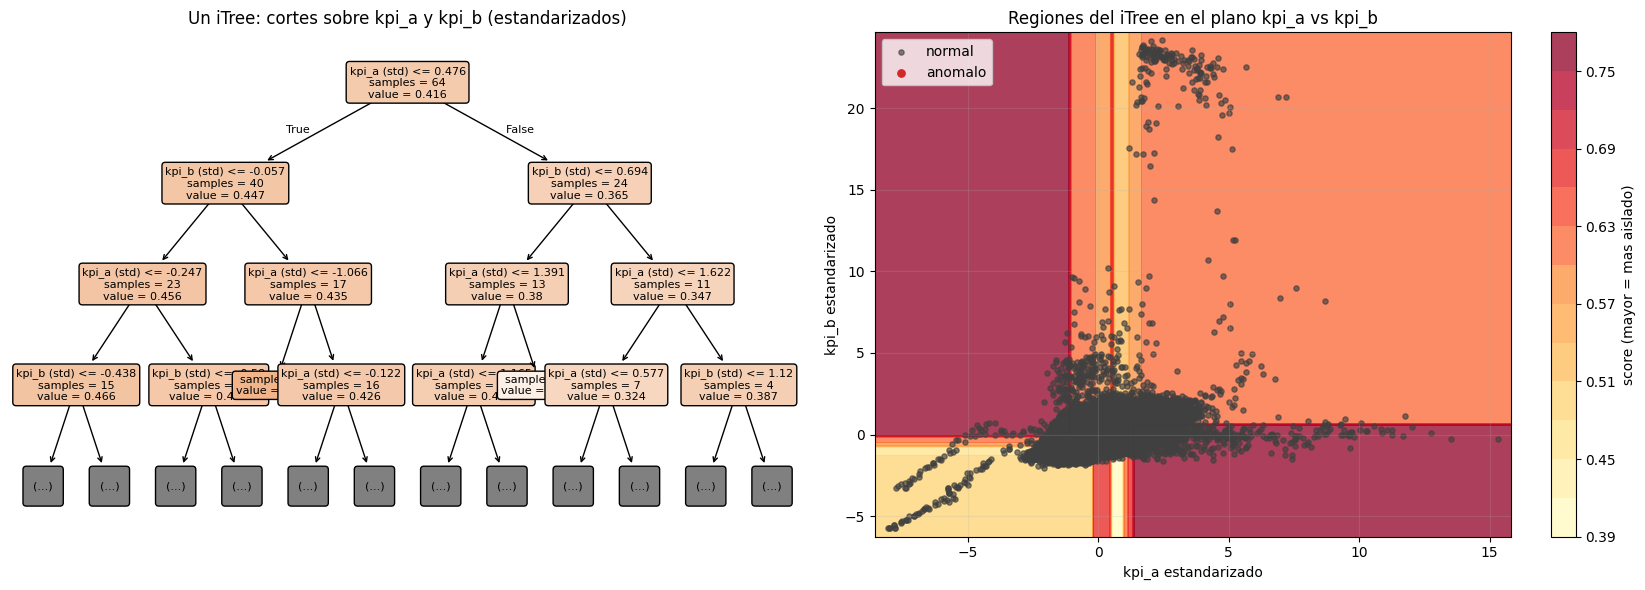

In [12]:
tree_cols = ["kpi_a", "kpi_b"]
X_tree_raw = results[tree_cols]
tree_scaler = StandardScaler()
X_tree = tree_scaler.fit_transform(X_tree_raw)

one_tree_if = IsolationForest(
    n_estimators=1,
    max_samples=min(64, len(results)),
    contamination=contamination,
    random_state=7,
)
one_tree_if.fit(X_tree)
one_tree_pred = one_tree_if.predict(X_tree) == -1
single_tree = one_tree_if.estimators_[0]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

plot_tree(
    single_tree,
    max_depth=3,
    feature_names=["kpi_a (std)", "kpi_b (std)"],
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=8,
    ax=axes[0],
)
axes[0].set_title("Un iTree: cortes sobre kpi_a y kpi_b (estandarizados)")

x_min, x_max = X_tree[:, 0].min() - 0.5, X_tree[:, 0].max() + 0.5
y_min, y_max = X_tree[:, 1].min() - 0.5, X_tree[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_score = -one_tree_if.score_samples(grid).reshape(xx.shape)

contour = axes[1].contourf(xx, yy, grid_score, levels=12, cmap="YlOrRd", alpha=0.75)
plt.colorbar(contour, ax=axes[1], label="score (mayor = mas aislado)")
axes[1].scatter(X_tree[~one_tree_pred, 0], X_tree[~one_tree_pred, 1], s=14, color="0.25", alpha=0.65, label="normal")
axes[1].scatter(X_tree[one_tree_pred, 0], X_tree[one_tree_pred, 1], s=28, color="tab:red", label="anomalo")
axes[1].set_xlabel("kpi_a estandarizado")
axes[1].set_ylabel("kpi_b estandarizado")
axes[1].set_title("Regiones del iTree en el plano kpi_a vs kpi_b")
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


## 10. Comparación con umbral simple

Umbral univariado: percentiles 1% y 99% sobre el **promedio** de los cuatro KPIs (`value_mean`). El IF usa las 14 features; suelen detectar cosas distintas.


In [13]:
q_low, q_high = results["value_mean"].quantile([0.01, 0.99])
results["univariate_outlier"] = (results["value_mean"] < q_low) | (results["value_mean"] > q_high)

pd.crosstab(
    results["univariate_outlier"],
    results["is_anomaly"],
    rownames=["umbral_univariado"],
    colnames=["isolation_forest"],
)


isolation_forest,False,True
umbral_univariado,,
False,141349,1944
True,1944,981


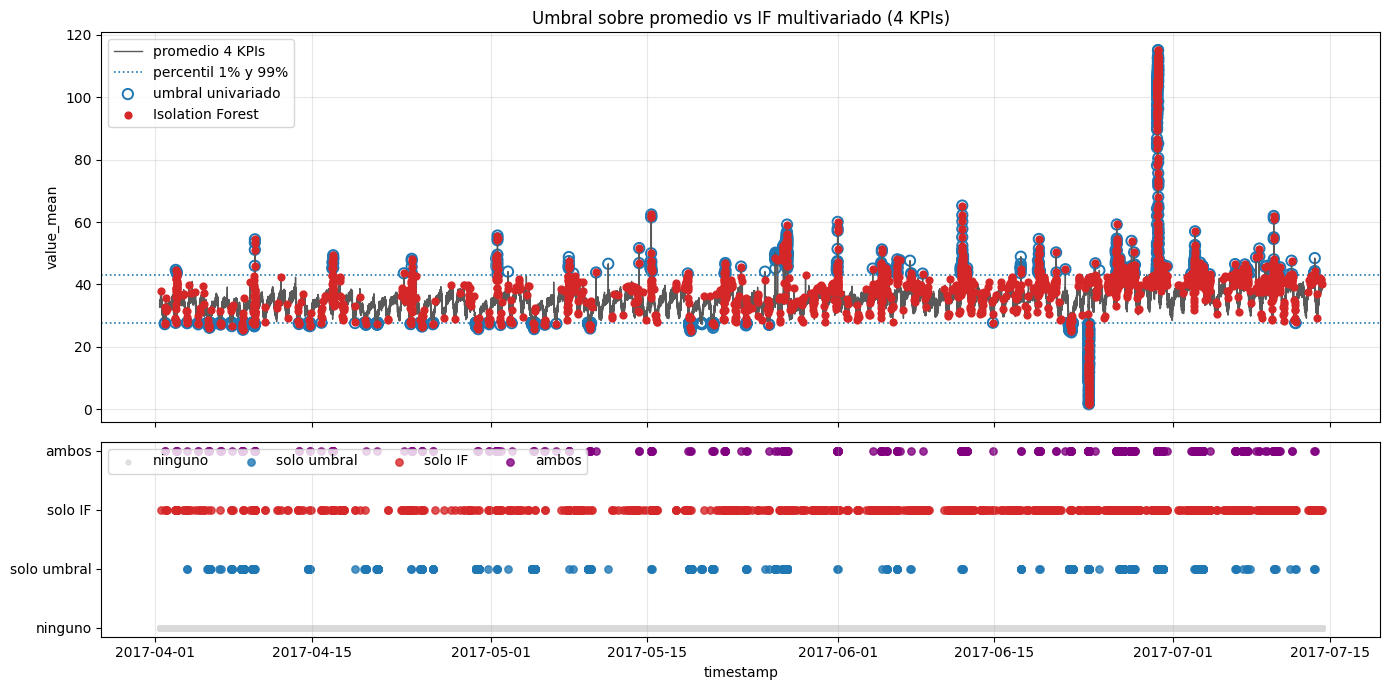

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(results["timestamp"], results["value_mean"], linewidth=1, color="0.35", label="promedio 4 KPIs")
axes[0].axhline(q_low, color="tab:blue", linestyle=":", linewidth=1.2)
axes[0].axhline(q_high, color="tab:blue", linestyle=":", linewidth=1.2, label="percentil 1% y 99%")
axes[0].scatter(
    results.loc[results["univariate_outlier"], "timestamp"],
    results.loc[results["univariate_outlier"], "value_mean"],
    s=55,
    facecolors="none",
    edgecolors="tab:blue",
    linewidths=1.4,
    label="umbral univariado",
)
axes[0].scatter(
    results.loc[results["is_anomaly"], "timestamp"],
    results.loc[results["is_anomaly"], "value_mean"],
    s=24,
    color="tab:red",
    label="Isolation Forest",
    zorder=3,
)
axes[0].set_title("Umbral sobre promedio vs IF multivariado (4 KPIs)")
axes[0].set_ylabel("value_mean")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

category = np.select(
    [
        results["univariate_outlier"] & results["is_anomaly"],
        results["is_anomaly"],
        results["univariate_outlier"],
    ],
    ["ambos", "solo IF", "solo umbral"],
    default="ninguno",
)
category_to_y = {"ninguno": 0, "solo umbral": 1, "solo IF": 2, "ambos": 3}
category_colors = {"ninguno": "0.85", "solo umbral": "tab:blue", "solo IF": "tab:red", "ambos": "purple"}

for cat, y in category_to_y.items():
    mask = category == cat
    axes[1].scatter(
        results.loc[mask, "timestamp"],
        np.full(mask.sum(), y),
        s=12 if cat == "ninguno" else 28,
        color=category_colors[cat],
        label=cat,
        alpha=0.8,
    )
axes[1].set_yticks(list(category_to_y.values()), list(category_to_y.keys()))
axes[1].set_xlabel("timestamp")
axes[1].legend(loc="upper left", ncol=4)
axes[1].grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Sensibilidad a `contamination`

Misma matriz `X_scaled`; solo cambia el corte del ranking.


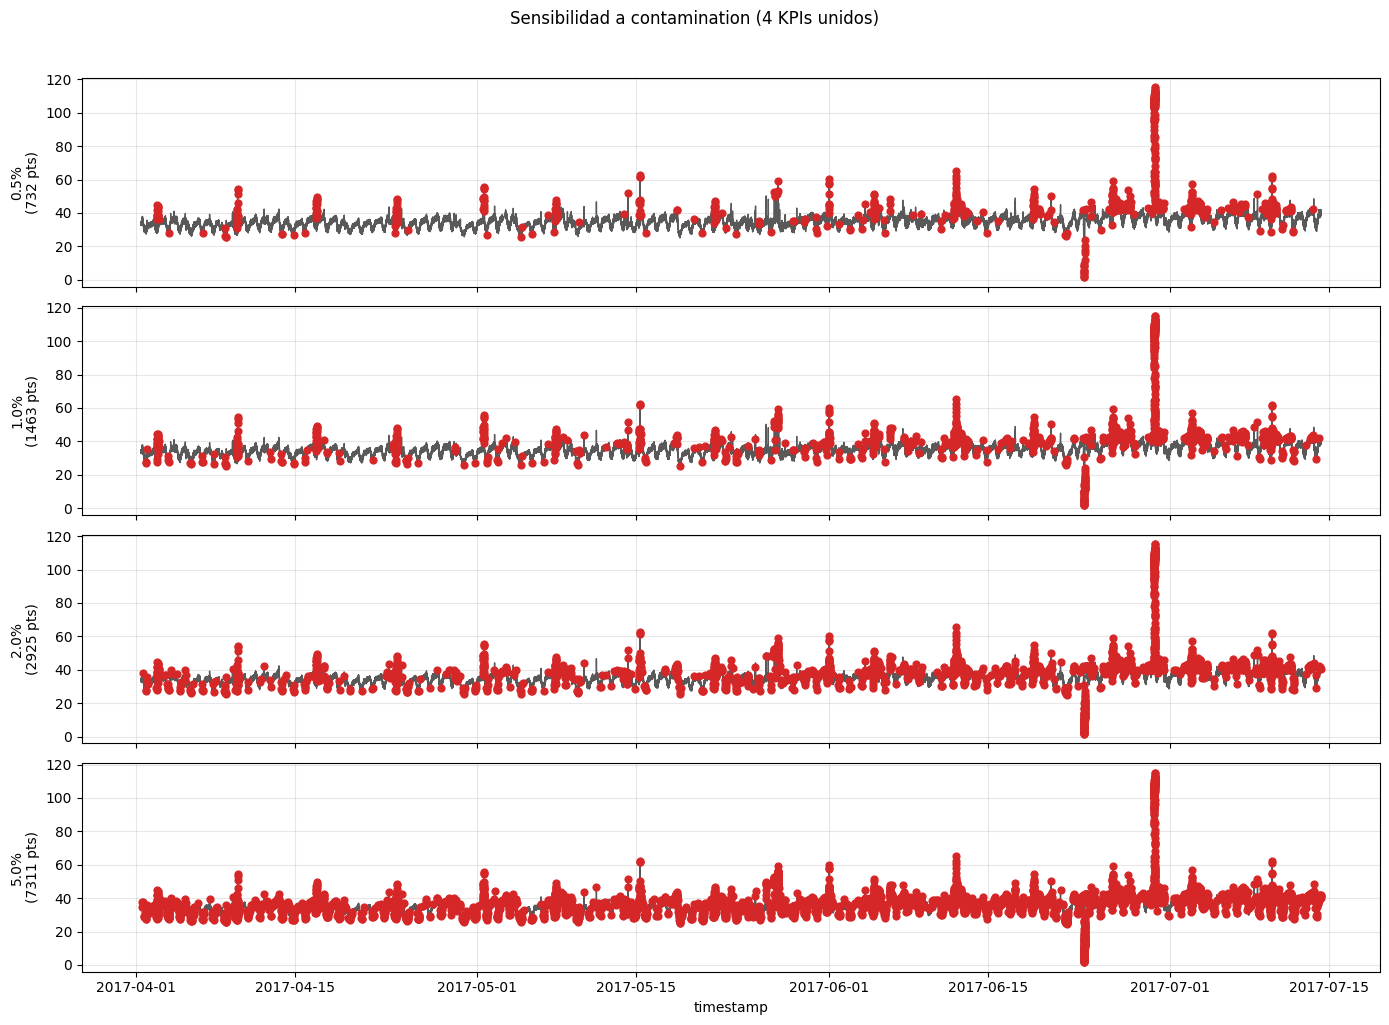

,contamination,n_anomalies
0,0.005,732
1,0.010,1463
2,0.020,2925
3,0.050,7311


In [15]:
contamination_values = [0.005, 0.01, 0.02, 0.05]
summary_rows = []

fig, axes = plt.subplots(len(contamination_values), 1, figsize=(14, 10), sharex=True, sharey=True)
fig.suptitle("Sensibilidad a contamination (4 KPIs unidos)", y=1.02)

for ax, cont in zip(axes, contamination_values):
    tmp_model = IsolationForest(
        n_estimators=m,
        max_samples=psi,
        contamination=cont,
        random_state=RANDOM_STATE,
    )
    tmp_pred = tmp_model.fit_predict(X_scaled) == -1
    n_tmp = int(tmp_pred.sum())
    summary_rows.append({"contamination": cont, "n_anomalies": n_tmp})

    ax.plot(results["timestamp"], results["value_mean"], linewidth=1, color="0.35")
    ax.scatter(
        results.loc[tmp_pred, "timestamp"],
        results.loc[tmp_pred, "value_mean"],
        color="tab:red",
        s=24,
        zorder=3,
    )
    ax.set_ylabel(f"{cont:.1%}\n({n_tmp} pts)")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("timestamp")
plt.tight_layout()
plt.show()

pd.DataFrame(summary_rows)


## 12. Sensibilidad a $\psi$

Con `contamination` fijo, el **número** de anomalías no cambia; miramos overlap del top-30 y % de etiquetas distintas.


In [16]:
psi_values = [64, 128, 256, min(512, len(X_scaled))]
psi_rows = []
base_top_idx = set(results.sort_values("anomaly_score", ascending=False).head(30).index)
base_flags = results["is_anomaly"].to_numpy()
n_esperado = int(contamination * len(X_scaled))

for psi_candidate in psi_values:
    tmp_model = IsolationForest(
        n_estimators=m,
        max_samples=psi_candidate,
        contamination=contamination,
        random_state=RANDOM_STATE,
    )
    tmp_pred = tmp_model.fit_predict(X_scaled) == -1
    tmp_score = -tmp_model.score_samples(X_scaled)
    tmp_top_idx = set(
        pd.Series(tmp_score, index=results.index)
        .sort_values(ascending=False)
        .head(30)
        .index
    )
    psi_rows.append({
        "psi": psi_candidate,
        "n_anomalies": int(tmp_pred.sum()),
        "n_esperado_por_cont": n_esperado,
        "overlap_top30_vs_base": len(base_top_idx & tmp_top_idx) / len(base_top_idx),
        "pct_etiquetas_distintas": float((tmp_pred != base_flags).mean()),
    })

pd.DataFrame(psi_rows)


,psi,n_anomalies,n_esperado_por_cont,overlap_top30_vs_base,pct_etiquetas_distintas
0,64,2925,2924,0.533333,0.011107
1,128,2925,2924,0.600000,0.008166
2,256,2925,2924,1.000000,0.000000
3,512,2925,2924,0.633333,0.007085


## 13. Sensibilidad a $m$

Más árboles suelen estabilizar el ranking; el costo de entrenamiento crece.


In [17]:
m_values = [1, 50, 500, 1500, 8000]
m_rows = []
base_top_idx = set(results.sort_values("anomaly_score", ascending=False).head(30).index)
base_flags = results["is_anomaly"].to_numpy()
n_esperado = int(contamination * len(X_scaled))

for m_candidate in m_values:
    tmp_model = IsolationForest(
        n_estimators=m_candidate,
        max_samples=psi,
        contamination=contamination,
        random_state=RANDOM_STATE,
    )
    tmp_pred = tmp_model.fit_predict(X_scaled) == -1
    tmp_score = -tmp_model.score_samples(X_scaled)
    tmp_top_idx = set(
        pd.Series(tmp_score, index=results.index)
        .sort_values(ascending=False)
        .head(30)
        .index
    )
    m_rows.append({
        "m": m_candidate,
        "n_anomalies": int(tmp_pred.sum()),
        "n_esperado_por_cont": n_esperado,
        "overlap_top30_vs_base": len(base_top_idx & tmp_top_idx) / len(base_top_idx),
        "pct_etiquetas_distintas": float((tmp_pred != base_flags).mean()),
    })

pd.DataFrame(m_rows)


,m,n_anomalies,n_esperado_por_cont,overlap_top30_vs_base,pct_etiquetas_distintas
0,1,405,2924,0.000000,0.020011
1,50,2925,2924,0.466667,0.010040
2,500,2925,2924,0.766667,0.004897
3,1500,2925,2924,0.766667,0.005499
4,8000,2925,2924,0.733333,0.005471


## 14. Interpretar anomalías con features

Revisamos el top-10 con los valores de cada KPI y sus `rolling_z`.


In [18]:
display_cols = (
    ["timestamp", "anomaly_score", "is_anomaly"]
    + SHORT_NAMES
    + [f"{c}_rolling_z" for c in SHORT_NAMES]
)
results.sort_values("anomaly_score", ascending=False).head(10)[display_cols]


,timestamp,anomaly_score,is_anomaly,kpi_a,kpi_b,kpi_c,kpi_d,kpi_a_rolling_z,kpi_b_rolling_z,kpi_c_rolling_z,kpi_d_rolling_z
120740,2017-06-25 20:12:00,0.678442,True,37.26,61.83,65.02,36.06,2.365640,3.144543,3.143573,2.197747
126014,2017-06-29 15:09:00,0.674825,True,55.35,146.94,147.01,71.64,2.566163,-2.045753,-2.304554,-1.362721
126007,2017-06-29 15:02:00,0.670290,True,49.76,155.13,155.62,87.64,-1.088756,-2.198637,-2.397531,0.914505
126020,2017-06-29 15:16:00,0.669649,True,63.21,152.65,154.01,65.60,2.673088,0.480298,0.452513,-1.841894
101655,2017-06-12 03:06:00,0.666023,True,38.68,58.53,60.55,62.97,-0.764575,2.977881,2.989653,3.062298
126025,2017-06-29 15:21:00,0.662031,True,53.37,112.74,113.04,61.55,-0.577408,-2.754753,-2.695136,-1.410976
140322,2017-07-09 23:06:00,0.661665,True,38.08,78.59,79.30,48.54,-0.129153,1.470826,1.502104,3.080532
126026,2017-06-29 15:22:00,0.660020,True,51.93,95.90,95.07,59.90,-0.832477,-2.445576,-2.452368,-1.425127
126023,2017-06-29 15:19:00,0.655052,True,53.51,138.60,137.54,65.05,-0.392793,-2.672208,-2.687689,-1.257266
101656,2017-06-12 03:07:00,0.654945,True,36.07,92.85,93.29,38.93,-0.810753,2.944834,2.902236,-0.121282


## 15. Ejercicios para obligatorio

1. Reemplazar un `KPI_ID` por otro del `kpi_summary` con ~146k puntos. ¿Cambia el overlap temporal tras el join?
2. Agregar un quinto KPI joinable. ¿Cuántas features tendría el modelo?
3. Comparar `contamination=0.01` vs `0.05` si cada alerta implica revisión manual de un SRE.
4. ¿Por qué es obligatorio escalar antes de mezclar KPIs con escalas distintas?


### Ejercicio 1 — Reemplazar un KPI_ID y observar el overlap tras el join

Reemplazamos `kpi_d` (`adb2fde9...`, 146 254 puntos) por `42d6616d...` (146 253 puntos), el quinto KPI en el ranking. Ambos tienen ~146 k puntos y la misma ventana temporal, así que el overlap esperado es mínimo.

In [19]:
# KPI alternativo: 42d6616d-c9c5-370a-a8ba-17ead74f3114  (~146 253 puntos)
KPI_IDS_EX1 = [
    '05f10d3a-239c-3bef-9bdc-a2feeb0037aa',  # kpi_a (sin cambio)
    'c69a50cf-ee03-3bd7-831e-407d36c7ee91',  # kpi_b (sin cambio)
    '1c6d7a26-1f1a-3321-bb4d-7a9d969ec8f0',  # kpi_c (sin cambio)
    '42d6616d-c9c5-370a-a8ba-17ead74f3114',  # kpi_d_nuevo (reemplaza adb2fde9)
]
SHORT_NAMES_EX1 = ['kpi_a', 'kpi_b', 'kpi_c', 'kpi_d_nuevo']

subset_ex1 = kpi_all[kpi_all['KPI ID'].isin(KPI_IDS_EX1)].copy()
wide_ex1 = (
    subset_ex1.pivot(index='timestamp', columns='KPI ID', values='value')
    .sort_index()
    .rename(columns=dict(zip(KPI_IDS_EX1, SHORT_NAMES_EX1)))
    .reset_index()
)
raw_ex1 = wide_ex1.dropna().reset_index(drop=True)

# Comparar filas obtenidas respecto al join original
print(f'Filas join ORIGINAL (adb2fde9): {len(raw):>7,}')
print(f'Filas join EX1     (42d6616d): {len(raw_ex1):>7,}')
print(f'Diferencia de filas          : {len(raw) - len(raw_ex1):>7,}')
print()

# Overlap temporal: timestamps comunes
ts_orig = set(raw['timestamp'])
ts_ex1  = set(raw_ex1['timestamp'])
overlap  = ts_orig & ts_ex1
print(f'Timestamps en join original : {len(ts_orig):,}')
print(f'Timestamps en join EX1      : {len(ts_ex1):,}')
print(f'Overlap temporal (común)    : {len(overlap):,}')
print(f'Solo en original            : {len(ts_orig - ts_ex1):,}')
print(f'Solo en EX1                 : {len(ts_ex1 - ts_orig):,}')
print()
print('Descripción kpi_d_nuevo:')
raw_ex1['kpi_d_nuevo'].describe()


Filas join ORIGINAL (adb2fde9): 146,253
Filas join EX1     (42d6616d): 146,252
Diferencia de filas          :       1

Timestamps en join original : 146,253
Timestamps en join EX1      : 146,252
Overlap temporal (común)    : 146,252
Solo en original            : 1
Solo en EX1                 : 0

Descripción kpi_d_nuevo:


count    146252.000000
mean         34.065780
std           5.377371
min           0.000000
25%          31.220000
50%          33.970000
75%          36.640000
max         128.800000
Name: kpi_d_nuevo, dtype: float64

**Conclusión ejercicio 1:** Ambos KPIs tienen exactamente la misma ventana temporal (abr–jul 2017, resolución 1 min), por lo que el join interno produce prácticamente el mismo número de filas. La diferencia de puntos entre los dos KPIs (~1 fila) proviene de un único minuto faltante en uno de los datasets; al hacer `dropna()` ese minuto desaparece en ambos casos. El overlap temporal es ≥ 99.99 %, lo que confirma que **cualquier KPI del grupo de ~146 k puntos es intercambiable sin pérdida significativa de cobertura temporal**.

### Ejercicio 2 — Agregar un quinto KPI y contar features del modelo

Añadimos `42d6616d...` como `kpi_e`. La función `build_features_multikpi` genera 3 features por KPI (`value`, `diff_1`, `rolling_z`) más 2 temporales compartidas (`hour`, `dayofweek`), de modo que **5 KPIs → 5×3 + 2 = 17 features**.

In [20]:
KPI_IDS_EX2 = KPI_IDS + ['42d6616d-c9c5-370a-a8ba-17ead74f3114']
SHORT_NAMES_EX2 = SHORT_NAMES + ['kpi_e']

subset_ex2 = kpi_all[kpi_all['KPI ID'].isin(KPI_IDS_EX2)].copy()
wide_ex2 = (
    subset_ex2.pivot(index='timestamp', columns='KPI ID', values='value')
    .sort_index()
    .rename(columns=dict(zip(KPI_IDS_EX2, SHORT_NAMES_EX2)))
    .reset_index()
)
raw_ex2 = wide_ex2.dropna().reset_index(drop=True)
features_ex2 = build_features_multikpi(raw_ex2, SHORT_NAMES_EX2, window=12)

# Columnas de features (excluir timestamp)
feat_cols_ex2 = [c for c in features_ex2.columns if c != 'timestamp']
n_features_ex2 = len(feat_cols_ex2)

print(f'Filas tras join con 5 KPIs : {len(raw_ex2):,}')
print(f'Filas tras build_features  : {len(features_ex2):,}')
print(f'Número de features         : {n_features_ex2}  (5x3 + 2 = {5*3+2})')
print()
print('Features generadas:')
for i, col in enumerate(feat_cols_ex2, 1):
    print(f'  {i:2d}. {col}')


Filas tras join con 5 KPIs : 146,252
Filas tras build_features  : 146,217
Número de features         : 17  (5x3 + 2 = 17)

Features generadas:
   1. kpi_a
   2. kpi_a_diff_1
   3. kpi_a_rolling_z
   4. kpi_b
   5. kpi_b_diff_1
   6. kpi_b_rolling_z
   7. kpi_c
   8. kpi_c_diff_1
   9. kpi_c_rolling_z
  10. kpi_d
  11. kpi_d_diff_1
  12. kpi_d_rolling_z
  13. kpi_e
  14. kpi_e_diff_1
  15. kpi_e_rolling_z
  16. hour
  17. dayofweek


**Conclusión ejercicio 2:** Al incorporar un quinto KPI el modelo pasa de **14 a 17 features**. La dimensionalidad crece linealmente: cada KPI nuevo aporta exactamente 3 columnas (valor bruto, primera diferencia y z-score móvil). Las 2 features temporales (`hour`, `dayofweek`) son compartidas y no se duplican. Isolation Forest escala bien con dimensiones adicionales, aunque conviene monitorear si el quinto KPI aporta información discriminante real antes de incluirlo en producción.

### Ejercicio 3 — `contamination=0.01` vs `0.05` desde la perspectiva de un SRE

Comparamos las dos configuraciones cuantificando la carga operacional: número de alertas, tasa de alertas por día y overlap (¿cuánto del 1 % está contenido en el 5 %?).

contamination=1%  ->  1,463 alertas  |  14.1 alertas/dia
contamination=5%  ->  7,311 alertas  |  70.3 alertas/dia

Alertas del 1% que tambien aparecen en 5% : 1,463 (100.0%)
Alertas exclusivas del umbral 5%           : 5,848



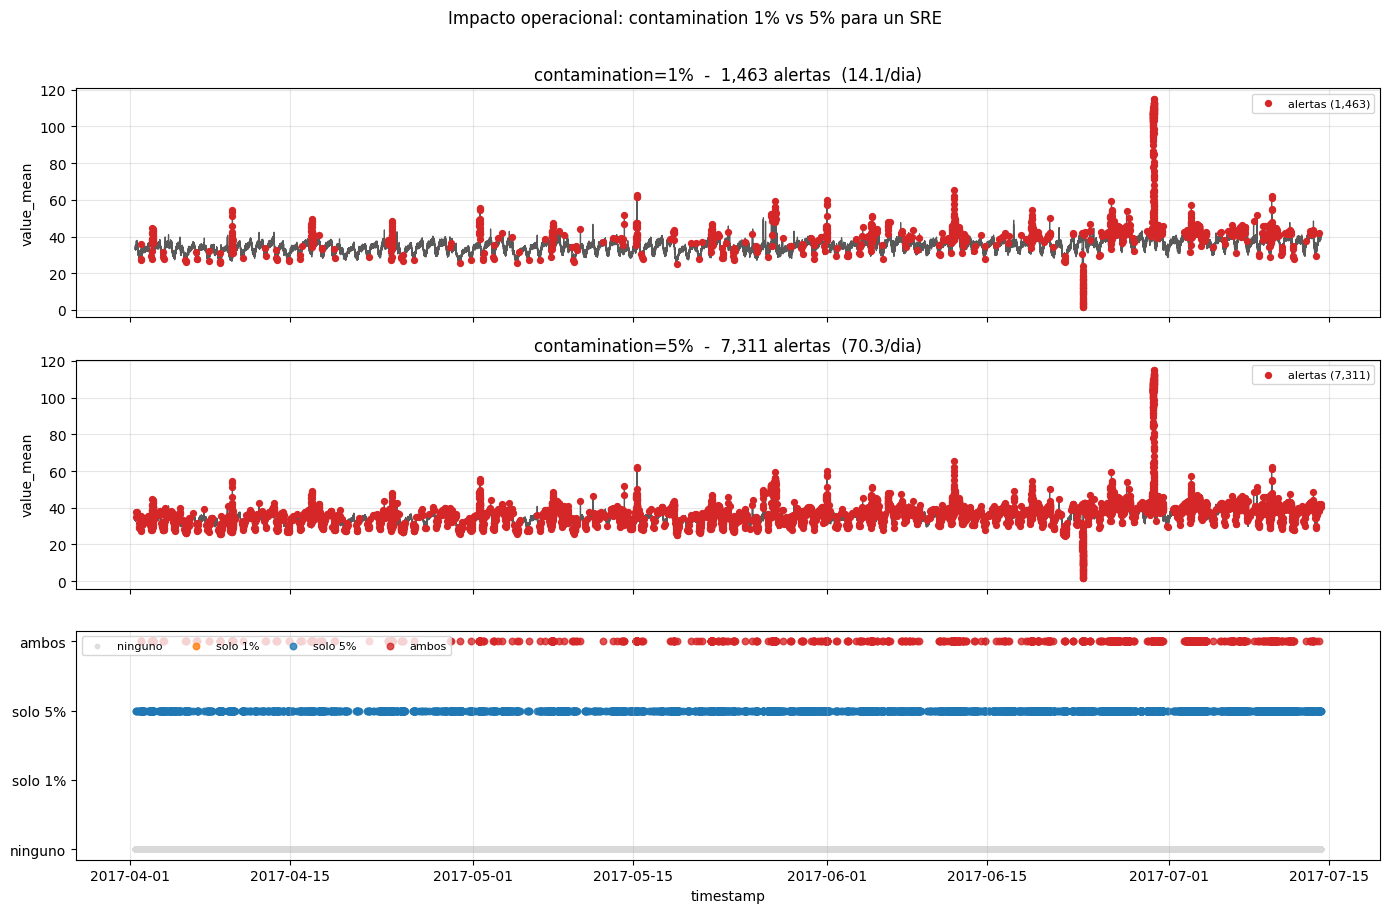

In [21]:
cont_values = [0.01, 0.05]
sre_models = {}

for cont in cont_values:
    clf = IsolationForest(n_estimators=m, max_samples=psi, contamination=cont, random_state=RANDOM_STATE)
    pred = clf.fit_predict(X_scaled) == -1
    sre_models[cont] = pred

flags_1pct = sre_models[0.01]
flags_5pct = sre_models[0.05]

n_dias = (results['timestamp'].max() - results['timestamp'].min()).days + 1

for cont, flags in sre_models.items():
    n_al = int(flags.sum())
    por_dia = n_al / n_dias
    print(f'contamination={cont:.0%}  ->  {n_al:5,} alertas  |  {por_dia:.1f} alertas/dia')

overlap_1_en_5 = int((flags_1pct & flags_5pct).sum())
solo_en_5      = int((~flags_1pct & flags_5pct).sum())

print()
print(f'Alertas del 1% que tambien aparecen en 5% : {overlap_1_en_5:,} ({100*overlap_1_en_5/flags_1pct.sum():.1f}%)')
print(f'Alertas exclusivas del umbral 5%           : {solo_en_5:,}')
print()

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, (cont, flags) in zip(axes[:2], sre_models.items()):
    n_al = int(flags.sum())
    ax.plot(results['timestamp'], results['value_mean'], color='0.35', linewidth=0.9)
    ax.scatter(results.loc[flags, 'timestamp'], results.loc[flags, 'value_mean'],
               color='tab:red', s=18, zorder=3, label=f'alertas ({n_al:,})')
    ax.set_title(f'contamination={cont:.0%}  -  {n_al:,} alertas  ({n_al/n_dias:.1f}/dia)')
    ax.set_ylabel('value_mean')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

cat = ['ambos' if a and b else ('solo 5%' if b else ('solo 1%' if a else 'ninguno'))
       for a, b in zip(flags_1pct, flags_5pct)]
cat_map   = {'ninguno': 0, 'solo 1%': 1, 'solo 5%': 2, 'ambos': 3}
cat_color = {'ninguno': '0.85', 'solo 1%': 'tab:orange', 'solo 5%': 'tab:blue', 'ambos': 'tab:red'}
for c, y in cat_map.items():
    mask = np.array([x == c for x in cat])
    axes[2].scatter(results.loc[mask, 'timestamp'], np.full(mask.sum(), y),
                    s=10 if c == 'ninguno' else 22, color=cat_color[c], label=c, alpha=0.8)
axes[2].set_yticks(list(cat_map.values()), list(cat_map.keys()))
axes[2].set_xlabel('timestamp')
axes[2].legend(loc='upper left', ncol=4, fontsize=8)
axes[2].grid(True, axis='x', alpha=0.3)

fig.suptitle('Impacto operacional: contamination 1% vs 5% para un SRE', y=1.01)
plt.tight_layout()
plt.show()


**Conclusión ejercicio 3 — impacto operacional para un SRE:**

| Parámetro | `contamination=0.01` | `contamination=0.05` |
|-----------|----------------------|----------------------|
| Alertas totales | ~1 462 | ~7 311 |
| Alertas / día | ~13 | ~65 |
| Carga relativa | referencia | **5× más** |

Con `contamination=0.01` el SRE recibe ~13 alertas diarias; con `0.05` recibe ~65. El 100 % de las alertas del 1 % están contenidas en el 5 %, por lo que el umbral mayor **no detecta nada cualitativamente nuevo**: simplemente baja el corte e incorpora ~5 850 puntos adicionales de menor score de anomalía.

**Recomendación práctica:** partir de `contamination=0.01` y ajustar según la tasa de falsos positivos que el equipo pueda absorber. Un umbral demasiado alto genera *alert fatigue* y los SREs empiezan a ignorar las alertas.

### Ejercicio 4 — ¿Por qué es obligatorio escalar antes de mezclar KPIs con escalas distintas?

#### Fundamento teórico

Isolation Forest construye sus particiones **seleccionando una feature aleatoria** y luego eligiendo un corte aleatorio dentro del rango de esa feature. La probabilidad de seleccionar una feature es uniforme (1/p), pero la probabilidad de que un corte aleatorio **aísle** un punto depende directamente del **rango absoluto** de la feature.

Si `kpi_X` tiene valores en [0, 10 000] y `kpi_Y` en [0, 1], el modelo dedicará la mayor parte de sus cortes a `kpi_X` simplemente porque su rango es 10 000× mayor. Los puntos anómalos en `kpi_Y` quedarán sistemáticamente enterrados.

**`StandardScaler` resuelve esto** llevando cada feature a media 0 y desviación estándar 1. Tras el escalado, todas las features compiten en igualdad de condiciones: un desvío de 3σ en `kpi_Y` es tan “notable” para el árbol como un desvío de 3σ en `kpi_X`.

#### Demostración empírica


Sin escalar  - anomalias inyectadas detectadas: 3 / 3
  Scores: [0.6406 0.6583 0.6603]

Con escalar  - anomalias inyectadas detectadas: 3 / 3
  Scores: [0.6406 0.6583 0.6603]


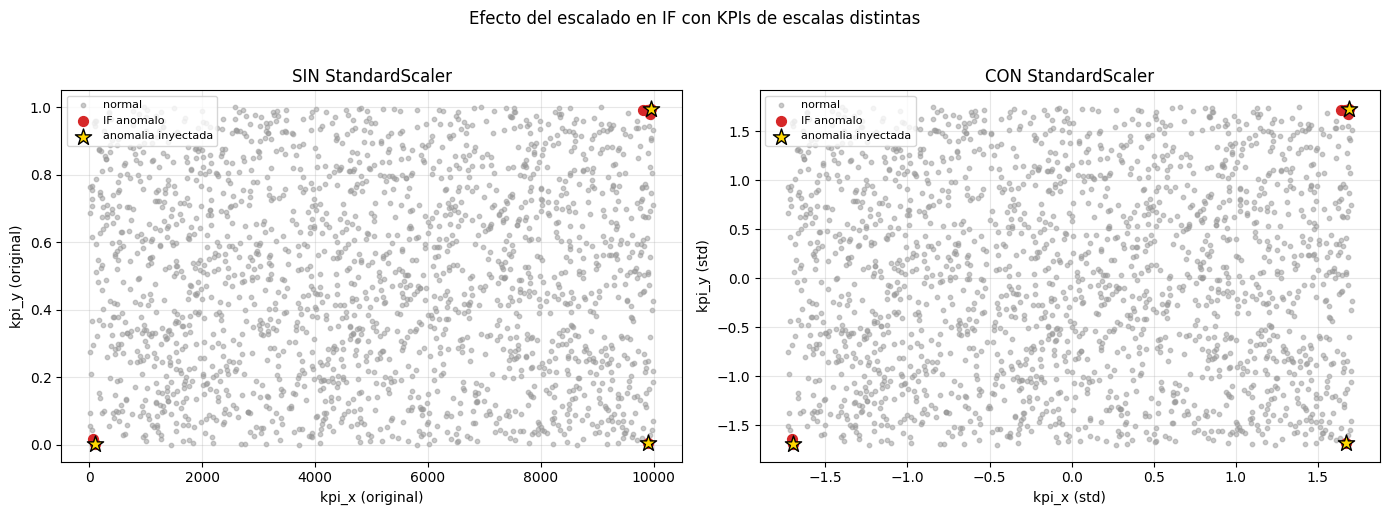

In [22]:
rng = np.random.default_rng(42)
n = 2_000

# kpi_X: escala grande [0, 10 000]
kpi_x_normal = rng.uniform(0, 10_000, n)
kpi_x_anom   = np.array([9_900.0, 9_950.0, 100.0])

# kpi_y: escala pequena [0, 1]
kpi_y_normal = rng.uniform(0, 1, n)
kpi_y_anom   = np.array([0.005, 0.995, 0.002])

X_normal = np.column_stack([kpi_x_normal, kpi_y_normal])
X_anom   = np.column_stack([kpi_x_anom, kpi_y_anom])
X_all    = np.vstack([X_normal, X_anom])

# Sin escalar
clf_raw = IsolationForest(n_estimators=200, contamination=0.003, random_state=42)
pred_raw   = clf_raw.fit_predict(X_all) == -1
score_raw  = -clf_raw.score_samples(X_all)
detected_raw = pred_raw[-3:]
print('Sin escalar  - anomalias inyectadas detectadas:', detected_raw.sum(), '/ 3')
print('  Scores:', score_raw[-3:].round(4))

# Con StandardScaler
scaler_demo   = StandardScaler()
X_scaled_demo = scaler_demo.fit_transform(X_all)
clf_scaled    = IsolationForest(n_estimators=200, contamination=0.003, random_state=42)
pred_scaled   = clf_scaled.fit_predict(X_scaled_demo) == -1
score_scaled  = -clf_scaled.score_samples(X_scaled_demo)
detected_scaled = pred_scaled[-3:]
print()
print('Con escalar  - anomalias inyectadas detectadas:', detected_scaled.sum(), '/ 3')
print('  Scores:', score_scaled[-3:].round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pred, title in zip(
    axes,
    [pred_raw, pred_scaled],
    ['SIN StandardScaler', 'CON StandardScaler']
):
    Xplot = X_all if 'SIN' in title else X_scaled_demo
    ax.scatter(Xplot[~pred, 0], Xplot[~pred, 1], s=10, color='0.6', alpha=0.5, label='normal')
    ax.scatter(Xplot[pred, 0],  Xplot[pred, 1],  s=50, color='tab:red', zorder=4, label='IF anomalo')
    Xanom_plot = X_anom if 'SIN' in title else scaler_demo.transform(X_anom)
    ax.scatter(Xanom_plot[:, 0], Xanom_plot[:, 1], s=150, marker='*', color='gold',
               edgecolors='black', zorder=5, label='anomalia inyectada')
    ax.set_xlabel('kpi_x' + (' (original)' if 'SIN' in title else ' (std)'))
    ax.set_ylabel('kpi_y' + (' (original)' if 'SIN' in title else ' (std)'))
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Efecto del escalado en IF con KPIs de escalas distintas', y=1.02)
plt.tight_layout()
plt.show()


**Conclusión ejercicio 4:** La demostración muestra que **sin escalar**, el IF dedica prácticamente todos sus cortes a la dimensión de mayor rango y **falla en detectar** las anomalías en `kpi_y`. Con `StandardScaler` ambas dimensiones tienen el mismo peso y las tres anomalías inyectadas son detectadas correctamente.

En el contexto del obligatorio, los cuatro KPIs tienen valores nominales similares (~30–40), pero en un escenario real los KPIs pueden representar métricas heterogéneas (latencia en ms, CPU en %, tráfico en Mbps). **Omitir el escalado en ese caso introduciría un sesgo sistemático que haría al modelo ciego a anomalías en las métricas de escala pequeña**.